In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
!module load latex

/mnt/sw/nix/store/7kfpfhj104s5hynnhr5jzsrm25p4vwla-python-3.11.11-view/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


# Imports, configuration & shared helpers

Run once after a kernel restart; Cells 1–3 build on these.

In [32]:
import os
import sys


sys.path.append("../src")

import jax
import jax.numpy as jnp
import numpy as np
import netket as nk
from netket.experimental.dynamics import RK45, Heun
from netket import stats
from flax import serialization

from logger import Logger
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from schmitt_tdvp import TDVPSchmitt
from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp_randomized_blur import TDVPSchmittRandomizedBlur

from schmitt_tdvp_overdispersed import TDVPSchmittOverdispersed

import matplotlib.pyplot as plt
import matplotlib
# =====================================================================
# Shared configuration & helpers (pure functions -- run once after the
# imports; Cells 1/2/3 below all build on these and can run in any order).
# =====================================================================
ALPHA_RBM = 4          # RBM hidden-unit density (model capacity)
G_PREP = 0.01           # transverse field of the *preparation* TFIM ground state
SEED = 100
N_SAMPLES_GS = 2**10   # MC samples for the SR ground-state search
N_SAMPLES_TVMC = 2**12 # MC samples during the quench
GS_DIR = "./data/ISING_GS"


def make_graph(N):
    return nk.graph.Chain(N, pbc=True)


def make_vstate(N, n_samples, graph, *, alpha_rbm=ALPHA_RBM, seed=SEED, machine_pow=2):
    """Complex RBM MCState. `machine_pow` sets the sampling power |psi|^machine_pow
    (=2 is standard VMC; the overdispersed driver wants a copy with machine_pow=alpha)."""
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    model = nk.models.RBMSymm(alpha=alpha_rbm, param_dtype=complex, symmetries=graph.translation_group())
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples, machine_pow=machine_pow)
    return nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=seed, sampler_seed=seed
    )


def prep_hamiltonian(N, g=G_PREP, J=1.0):
    """Transverse-field Ising chain (PBC):  H = -J sum_<ij> Z_i Z_j - g sum_i X_i."""
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    graph = make_graph(N)
    strings, coeffs = [], []
    for i, j in graph.edges():
        s = ["I"] * N; s[i] = "Z"; s[j] = "Z"
        strings.append("".join(s)); coeffs.append(-J)
    for i in range(N):
        s = ["I"] * N; s[i] = "X"
        strings.append("".join(s)); coeffs.append(-g)
    return nk.operator.PauliStringsJax(hilbert, strings, coeffs)


def quench_hamiltonian(N):
    """Local transverse field:  H = sum_i X_i."""
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    strings = ["I" * i + "X" + "I" * (N - i - 1) for i in range(N)]
    return nk.operator.PauliStringsJax(hilbert, strings, [1.0] * N)


def magnetization_op(N):
    """<Z> = (1/N) sum_i Z_i  (==0 for the symmetric TFIM GS, but logged as requested)."""
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    strings = ["I" * i + "Z" + "I" * (N - i - 1) for i in range(N)]
    return nk.operator.PauliStringsJax(hilbert, strings, [1.0 / N] * N)


def zz_correlation_op(N):
    """<ZZ> = (1/N) sum_i Z_i Z_{i+1}  (PBC) -- the dynamical order parameter."""
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    strings, coeffs = [], []
    for i, j in make_graph(N).edges():
        s = ["I"] * N; s[i] = "Z"; s[j] = "Z"
        strings.append("".join(s)); coeffs.append(1.0 / N)
    return nk.operator.PauliStringsJax(hilbert, strings, coeffs)


def gs_param_path(N, *, g=G_PREP, alpha_rbm=ALPHA_RBM):
    return f"{GS_DIR}/N{N}_RBM{alpha_rbm}_g{g:1.2f}.mpack"


EXACT_DIR = "./data/ISING_EXACT"


def get_quench_exact(N, *, g=G_PREP, T=2.0, n_points=200, use_cache=True):
    """Exact (ED) dynamics of the H = sum_i X_i quench started from the *exact*
    TFIM(g) ground state. Returns (times, mz, zz); cached to disk after run 1."""
    os.makedirs(EXACT_DIR, exist_ok=True)
    cache = f"{EXACT_DIR}/N{N}_g{g:1.2f}_T{T:1.2f}.npz"
    if use_cache and os.path.exists(cache):
        d = np.load(cache)
        return d["times"], d["mz"], d["zz"]

    import qutip as qt

    Hprep = qt.Qobj(prep_hamiltonian(N, g=g).to_sparse())
    H = qt.Qobj(quench_hamiltonian(N).to_sparse())
    Mz = qt.Qobj(magnetization_op(N).to_sparse())
    ZZ = qt.Qobj(zz_correlation_op(N).to_sparse())

    psi0 = Hprep.groundstate()[1]  # exact TFIM ground state

    times = np.linspace(0.0, T, n_points)
    # Unitary evolution (no collapse operators); observables via e_ops.
    result = qt.mesolve(H, psi0, times, c_ops=[], e_ops=[Mz, ZZ])
    mz = np.asarray(result.expect[0]).real
    zz = np.asarray(result.expect[1]).real
    if use_cache:
        np.savez(cache, times=times, mz=mz, zz=zz)
    return times, mz, zz

# Cell 1 — Prepare 1D TFIM ground states (SR) and cache parameters per N

In [33]:
# =====================================================================
# Cell 1 -- Prepare the 1D TFIM ground state via SR and cache the RBM
# parameters per N, so we never have to re-run SR.
# =====================================================================
N_LIST = [4]


def prepare_ground_state(
    N, *, g=G_PREP, alpha_rbm=ALPHA_RBM, n_samples=N_SAMPLES_GS,
    seed=SEED, n_iter=600, lr=0.02, diag_shift=1e-5, overwrite=False,
):
    """Optimize the TFIM ground state and save vstate.parameters to disk."""
    os.makedirs(GS_DIR, exist_ok=True)
    path = gs_param_path(N, g=g, alpha_rbm=alpha_rbm)
    if os.path.exists(path) and not overwrite:
        print(f"N={N}: cached at {path}, skipping SR.")
        return path

    H = prep_hamiltonian(N, g=g)
    graph = make_graph(N)
    vstate = make_vstate(N, n_samples, graph, alpha_rbm=alpha_rbm, seed=seed)

    gs = nk.driver.VMC_SR(
        H,
        optimizer=nk.optimizer.Sgd(learning_rate=lr),
        variational_state=vstate,
        diag_shift=diag_shift,
    )
    gs.run(n_iter)

    e_var = vstate.expect(H)
    msg = f"N={N}: variational E = {e_var.mean.real:.6f}"
    if N <= 14:
        e0 = float(np.asarray(nk.exact.lanczos_ed(H)).ravel()[0])
        msg += f"   (exact {e0:.6f}, err {e_var.mean.real - e0:.2e})"
    print(msg)

    with open(path, "wb") as f:
        f.write(serialization.to_bytes(vstate.parameters))
    print(f"   saved -> {path}")
    return path


for N in N_LIST:
    prepare_ground_state(N)

N=4: cached at ./data/ISING_GS/N4_RBM4_g0.01.mpack, skipping SR.


# Cell 2 — tVMC quench under $\sum_i X_i$ (Blur / Overdispersed / vanilla Schmitt)

In [ ]:
# =====================================================================
# Cell 2 -- tVMC quench under H = sum_i X_i, starting from the cached
# TFIM ground state. One entry point, `run_quench`, switches between the
# three drivers:
#   driver_type="vanilla"        -> TDVPSchmitt              (no extra param)
#   driver_type="blur"           -> TDVPSchmittBlur          (param = q)
#   driver_type="overdispersed"  -> TDVPSchmittOverdispersed (param = alpha/pow)
# =====================================================================
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("mz", "Mean"),
    ("mz", "Variance"),
    ("zz", "Mean"),
    ("zz", "Variance"),
    ("r_squared", "values"),
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values"),
)


def load_gs_vstate(
    N, n_samples, *, alpha_rbm=ALPHA_RBM, seed=SEED, g=G_PREP, machine_pow=2
):
    """Build an RBM vstate and load the cached ground-state parameters into it."""
    H= prep_hamiltonian(N, g=g)
    graph = make_graph(N)
    vstate = make_vstate(
        N, n_samples, graph, alpha_rbm=alpha_rbm, seed=seed, machine_pow=machine_pow
    )
    path = gs_param_path(N, g=g, alpha_rbm=alpha_rbm)
    if not os.path.exists(path):
        raise FileNotFoundError(f"No cached GS for N={N} at {path}. Run Cell 1 first.")
    with open(path, "rb") as f:
        vstate.parameters = serialization.from_bytes(vstate.parameters, f.read())
    vstate.parameters = jax.tree.map(jnp.asarray, vstate.parameters)
    return vstate


def quench_save_path(
    N, driver_type, param, n_samples, *, alpha_rbm=ALPHA_RBM, g=G_PREP
):
    if driver_type == "vanilla":
        exp = f"vanilla_{n_samples}"
    elif driver_type == "blur":
        exp = f"blur_{n_samples}_q_{param:1.2f}"
    elif driver_type == "randomized_blur":
        exp = f"rblur_{n_samples}_q_{param:1.2f}"
    elif driver_type == "overdispersed":
        exp = f"overdispersed_{n_samples}_alpha_{param:1.2f}"
    else:
        raise ValueError(f"unknown driver_type {driver_type!r}")
    return f"./data/ISING_QUENCH_{N}/RBM{alpha_rbm}_g{g:1.2f}/{exp}/"


def run_quench(
    N,
    driver_type,
    param=None,
    *,
    n_samples=N_SAMPLES_TVMC,
    alpha_rbm=ALPHA_RBM,
    g=G_PREP,
    T=2.0,
    n_save=40,
    seed=SEED,
    overwrite=False,
):
    """Quench the cached TFIM GS under sum_i X_i with the requested driver."""
    if driver_type in ("blur", "overdispersed") and param is None:
        raise ValueError(f"driver_type={driver_type!r} needs a `param`.")

    save_path = quench_save_path(
        N, driver_type, param, n_samples, alpha_rbm=alpha_rbm, g=g
    )
    os.makedirs(save_path, exist_ok=True)
    logger = Logger(path=save_path, fields=fields_to_track)
    if not overwrite and logger.restore() and logger.done:
        print(f"{save_path}: done, skipping.")
        return save_path

    H = quench_hamiltonian(N)
    graph = make_graph(N)
    mz_op, zz_op = magnetization_op(N), zz_correlation_op(N)
    vstate = load_gs_vstate(N, n_samples, alpha_rbm=alpha_rbm, seed=seed, g=g)

    def measure_observables(step, log, driver):
        
        if hasattr(driver, "importance_weights"):
            w = driver.importance_weights.flatten()
            mz_loc = driver.sampling_state.local_estimators(mz_op)
            zz_loc = driver.sampling_state.local_estimators(zz_op)
            log["mz"] = stats.statistics(w * mz_loc.flatten())
            log["zz"] = stats.statistics(w * zz_loc.flatten())
        else:
            log["mz"] = driver.state.expect(mz_op)
            log["zz"] = driver.state.expect(zz_op)
        return True

    save_times = np.linspace(0.0, T, n_save)
    callbacks = [
        measure_observables,
        get_acceptance_rate_callback(),
        get_parameter_save_callback(save_times, logger),
    ]
    callbacks.append(
        get_tdvp_monitor_callback(save_times, save_path)
        if driver_type == "vanilla"
        else get_umbrella_monitor_callback(save_times, save_path)
    )

    # integrator = RK45(1e-4, adaptive=True, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    integrator = Heun(1e-3)
    common = dict(t0=0.0, holomorphic=True, snr_atol=2, rcond=1e-14, rcond_smooth=1e-10)

    # thermalize the chains at the initial state
    for _ in range(100):
        vstate.sample()

    if driver_type == "vanilla":
        driver = TDVPSchmitt(H, vstate, integrator, **common)
    elif driver_type == "blur":
        driver = TDVPSchmittBlur(H, vstate, integrator, q=param, **common)
    elif driver_type == "randomized_blur":
        driver = TDVPSchmittRandomizedBlur(
            H, vstate, integrator, q1=param, q2=param, **common
        )
    elif driver_type == "overdispersed":
        # proposal q(x) ∝ |psi|^alpha needs a twin state sampling at machine_pow=alpha
        sampling_state = make_vstate(
            N, n_samples, graph, alpha_rbm=alpha_rbm, seed=seed, machine_pow=param
        )
        sampling_state.parameters = vstate.parameters
        # Warm up the proposal chains so q(x) is actually sampled near equilibrium.
        for _ in range(100):
            sampling_state.sample()
        driver = TDVPSchmittOverdispersed(
            H, vstate, integrator, alpha=param, sampling_state=sampling_state, **common
        )

    driver.run(T, out=logger, callback=callbacks, show_progress=True, timeit=True)
    logger.flush(vstate, done=True)
    return save_path

# Cell 3 — Parameter sweep

In [39]:
# =====================================================================
# Cell 3 -- Run the quench for the three drivers across a parameter sweep.
# Idempotent: finished runs are skipped (pass overwrite=True to force).
# =====================================================================
N = 4
T = 1.0
n_samples = N_SAMPLES_TVMC

# Baseline: standard tVMC
run_quench(N, "vanilla", n_samples=n_samples, T=T)

# Blurred bridge sampling: sweep q in [0, 1)
for q in [0.3, ]:
    # run_quench(N, "blur", param=q, n_samples=n_samples, T=T)
    run_quench(N, "randomized_blur", param=q, n_samples=n_samples, T=T)

# Overdispersed proposal q(x) ∝ |psi|^alpha: sweep alpha in (0, 2]  (2 == vanilla)
for alpha in [0.5, 1.5]:
    run_quench(N, "overdispersed", param=alpha, n_samples=n_samples, T=T)

# To sweep system size too, wrap the above in:  for N in N_LIST: ...

./data/ISING_QUENCH_4/RBM4_g0.01/vanilla_4096/: done, skipping.
./data/ISING_QUENCH_4/RBM4_g0.01/rblur_4096_q_0.30/: done, skipping.
File not found


  0%|          | 0.00/1.00 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 48.192                                                                                                   │
│ ├── (22.1%) | MCState.expect : 10.661 s                                                                         │
│ │   └── (58.1%) | MCState.sample : 6.191 s                                                                      │
│ │       └── (61.9%) | sampling n_discarded samples : 3.832 s                                                    │
│ ├── (21.0%) | MCState.sample : 10.107 s                                                                         │
│ │   └── (66.1%) | sampling n_discarded samples : 6.676 s                                                        │
│ ├── (4.6%) | QGTJacobian_DefaultConstructor : 2.207 s                                                           │
│ │   └── (50.8%) | jacobian : 1.121 s                                  

  0%|          | 0.00/1.00 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 44.893                                                                                                   │
│ ├── (21.0%) | MCState.expect : 9.413 s                                                                          │
│ │   └── (60.6%) | MCState.sample : 5.705 s                                                                      │
│ │       └── (63.7%) | sampling n_discarded samples : 3.634 s                                                    │
│ ├── (21.2%) | MCState.sample : 9.511 s                                                                          │
│ │   └── (67.6%) | sampling n_discarded samples : 6.425 s                                                        │
│ ├── (4.8%) | QGTJacobian_DefaultConstructor : 2.136 s                                                           │
│ │   └── (50.5%) | jacobian : 1.078 s                                  

# Compare drivers

         Run the ITensor script first:
             julia --project=. tfim_quench_itensor.jl


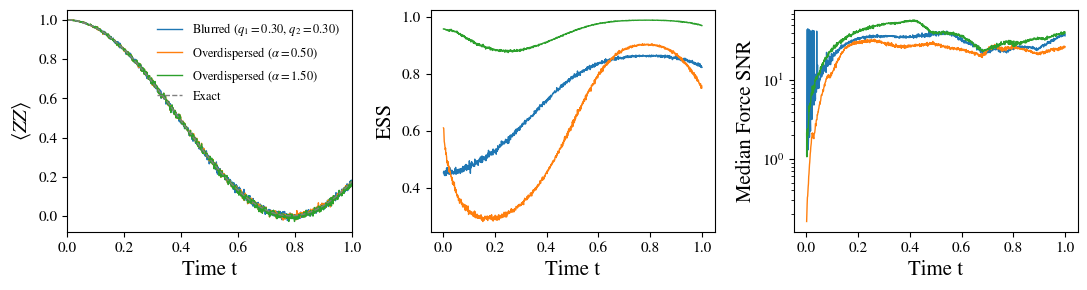

: 

In [ ]:
# =====================================================================
# (bonus) Compare the drivers: <ZZ>(t) and the bridge ESS over time.
# <Z> is also loaded but is ~0 for the symmetric TFIM GS (Z2 symmetry).
# =====================================================================
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
N = 4
n_samples = N_SAMPLES_TVMC

runs = [("vanilla", None) ]
runs = []

runs += [("randomized_blur", q) for q in [0.3]]
runs += [("overdispersed", a) for a in [0.5, 1.5 ]]

fig, (ax_obs, ax_ess, ax_snr) = plt.subplots(1, 3, figsize=(11, 3))
for driver_type, param in runs:
    sp = quench_save_path(N, driver_type, param, n_samples)
    lg = Logger(path=sp, fields=fields_to_track)
    if not lg.restore():
        print("missing:", sp)
        continue
    t = np.array(lg.data["t"]["values"])
    zz = np.array(lg.data["zz"]["Mean"]).real
    if driver_type=="randomized_blur":
        label=f"Blurred ($q_1=${param:1.2f}, $q_2=${param:1.2f})"
    elif driver_type=="overdispersed":
        label=fr"Overdispersed ($\alpha=${param:1.2f})"
    else:
        label="Standard"
    ax_obs.plot(t[:len(zz)], zz, label=label, lw=1)
    ess = np.asarray(lg.data["ess_bridge"]["values"])
    if not ess.size:
        ess = np.ones_like(t)
    ax_ess.plot(t[: len(ess)], ess, label=label, lw=1)
    snr_med = np.asarray(lg.data["snrF_med"]["values"])
    if snr_med.size:
        ax_snr.plot(t[: len(snr_med)], snr_med, label=label, lw=1)

# Exact (ED) reference
itensor_csv = f"./data/ISING_EXACT/tfim_quench_itensor_N{N}_g{G_PREP:.2f}.csv"

if not os.path.exists(itensor_csv):
    print(
        f"WARNING: {itensor_csv} not found.\n"
        f"         Run the ITensor script first:\n"
        f"             julia --project=. tfim_quench_itensor.jl"
    )
else:
    data = np.genfromtxt(itensor_csv, delimiter=",", names=True)
    t_it, mz_it, zz_it = data["t"], data["mz"], data["zz"]

ax_obs.plot(t_it, zz_it, linestyle="dashed", color="gray",lw=1, label="Exact")
ax_obs.set_xlim(0,1)
ax_obs.set_xlabel("Time t", fontsize=15); ax_obs.set_ylabel(r"$\langle ZZ \rangle$", fontsize=15)
ax_obs.legend(fontsize=9,frameon=False)
ax_ess.set_xlabel("Time t", fontsize=15); ax_ess.set_ylabel("ESS", fontsize=15)
ax_snr.set_xlabel("Time t", fontsize=15); ax_snr.set_ylabel("Median Force SNR", fontsize=15)
ax_snr.set_yscale('log')
for ax in (ax_obs, ax_ess, ax_snr):
    ax.tick_params(labelsize=11)
fig.tight_layout()
fig.savefig(f"Fig9.pdf", bbox_inches="tight", pad_inches=0.01)